<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Random Forest on Titanic Dataset</b>
</h1>

<div style="font-family:'Times New Roman';">

<b>Goal:</b>

<ol>
<li>Perform exploratory data analysis on the Titanic dataset.</li>
<li>Handle missing values and categorical features.</li>
<li>Train a Random Forest classifier.</li>
<li>Understand which features influence survival the most.</li>
</ol>

In this notebook, I'll use the Titanic dataset to predict whether a passenger survived or not based on different passenger attributes.

</div>

In [28]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [29]:
# load data

train = pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
# basic info

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [31]:
# dataset shape

print("Shape :", train.shape)

Shape : (891, 12)


In [32]:
# missing values

train.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Missing Values</b>
</h2>

<div style="font-family:'Times New Roman';">

The Titanic dataset contains missing values in some columns.

Features such as Age, Cabin and Embarked require cleaning before training the model.

Handling missing values is an important step in real-world machine learning projects.

</div>

In [33]:
# target distribution

train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

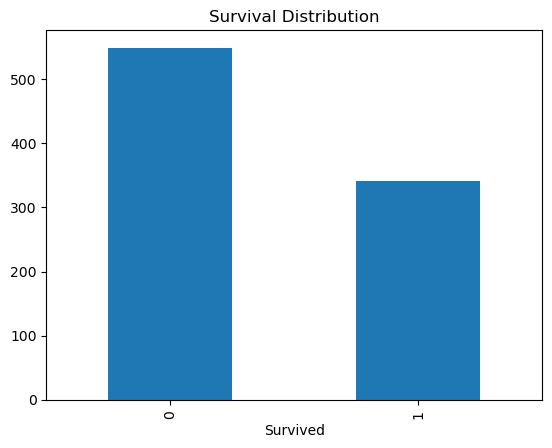

In [34]:
# visualize target

train["Survived"].value_counts().plot(
    kind="bar"
)

plt.title("Survival Distribution")

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Target Variable</b>
</h2>

<div style="font-family:'Times New Roman';">

<ul>
<li><b>0:</b> Did Not Survive</li>
<li><b>1:</b> Survived</li>
</ul>

This is a binary classification problem.

</div>

In [35]:
# survival by gender

pd.crosstab(
    train["Sex"],
    train["Survived"]
)

Survived,0,1
Sex,,
female,81,233
male,468,109


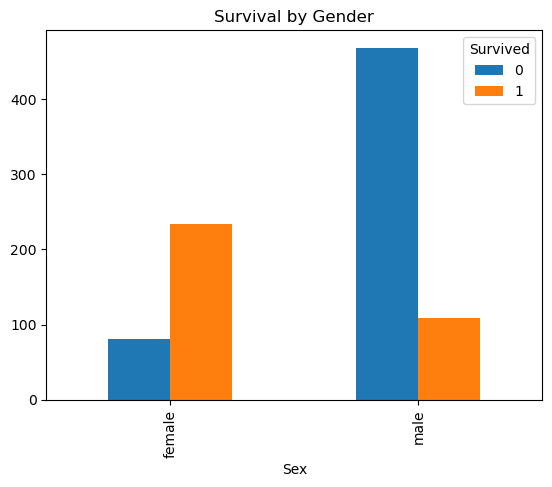

In [36]:
# plot

pd.crosstab(
    train["Sex"],
    train["Survived"]
).plot(kind="bar")

plt.title("Survival by Gender")

plt.show()

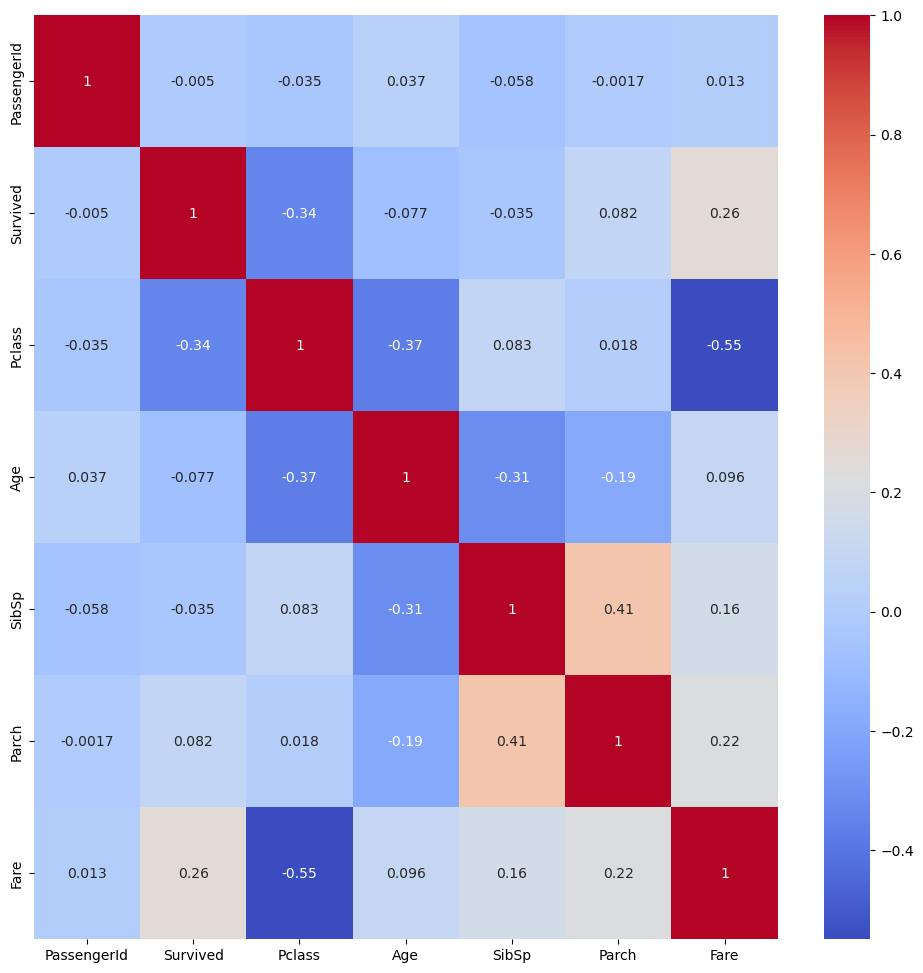

In [37]:
# correlation heatmap features

import seaborn as sns

plt.figure(figsize=(12,12))

sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Initial Observations</b>
</h2>

<div style="font-family:'Times New Roman';">

Some features appear to have a stronger relationship with survival than others.

Passenger class, fare and gender seem to be important factors.

We'll let Random Forest identify the most useful features later.

</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Data Cleaning</b>
</h2>

In [38]:
# fill age

train["Age"] = train["Age"].fillna(
    train["Age"].median()
)

In [39]:
# fill embarked

train["Embarked"] = train["Embarked"].fillna(
    train["Embarked"].mode()[0]
)

In [40]:
# drop cabin

train = train.drop(
    columns=["Cabin"]
)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Encoding</b>
</h2>

In [41]:
# encode categorical columns

train = pd.get_dummies(
    train,
    columns=["Sex","Embarked"],
    drop_first=True
)

In [42]:
# features

X = train.drop(columns=["PassengerId","Name","Ticket","Survived"])

y = train["Survived"]

In [43]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
# random forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
# predictions

y_pred = rf.predict(X_test)

In [46]:
# accuracy

acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(acc,4))

Accuracy : 0.8212


In [47]:
# confusion matrix

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[91 14]
 [18 56]]


In [48]:
# classification report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [49]:
# feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
5,Sex_male,0.273374
4,Fare,0.272705
1,Age,0.252215
0,Pclass,0.078450
2,SibSp,0.052163
3,Parch,0.038440
7,Embarked_S,0.023141
6,Embarked_Q,0.009512


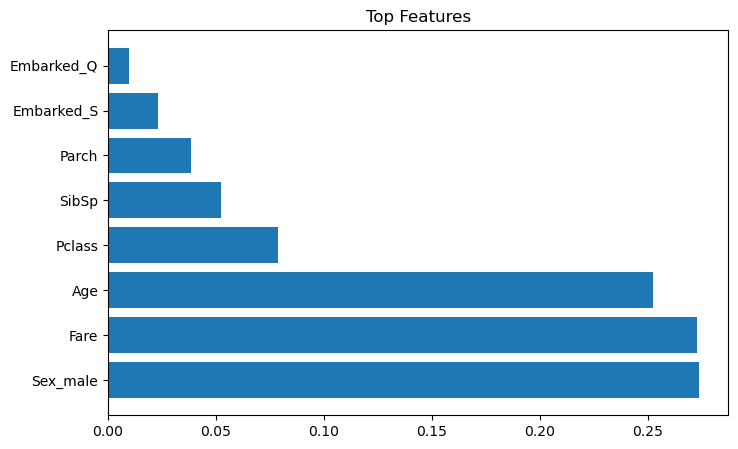

In [50]:
# visualize importance

top = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.title("Top Features")

plt.show()

In [51]:
# load kaggle test data

test_df = pd.read_csv("test.csv")

test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [52]:
# fill missing values

test_df["Age"] = test_df["Age"].fillna(
    test_df["Age"].median()
)

test_df["Fare"] = test_df["Fare"].fillna(
    test_df["Fare"].median()
)

test_df["Embarked"] = test_df["Embarked"].fillna(
    "S"
)

In [53]:
# drop cabin

test_df = test_df.drop(
    columns=["Cabin"]
)

In [54]:
# save passenger ids

passenger_ids = test_df["PassengerId"]

In [55]:
# encode categorical columns

test_df = pd.get_dummies(
    test_df,
    columns=["Sex","Embarked"],
    drop_first=True
)

In [56]:
# keep only model features

test_df = test_df.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket"
    ]
)

In [57]:
# make test columns same as train columns

test_df = test_df.reindex(columns=X.columns,fill_value=0)

In [58]:
# predict

test_predictions = rf.predict(test_df)

test_predictions[:10]

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [59]:
# create submission file

submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Conclusion</b>
</h2>

<div style="font-family:'Times New Roman';">

<ul>
<li>Random Forest was able to achieve an accuracy of <b>82.12%</b> on the Titanic dataset.</li>

<li>The model handled both numerical and categorical features after data cleaning and encoding.</li>

<li>Missing values had to be treated before training, showing the importance of data preprocessing in real-world projects.</li>

<li>The model achieved balanced Precision and Recall scores, indicating that it performed reasonably well across both classes.</li>

<li>Compared to datasets like Iris and Breast Cancer, the Titanic dataset was more challenging because of missing values, mixed feature types and less clear patterns.</li>

<li>Random Forest reduced the risk of overfitting by combining predictions from multiple Decision Trees.</li>
</ul>

<b>Key Results:</b>

<ul>
<li><b>Accuracy:</b> 82.12%</li>
<li><b>Precision:</b> 0.83 (Class 0), 0.80 (Class 1)</li>
<li><b>Recall:</b> 0.87 (Class 0), 0.76 (Class 1)</li>
<li><b>F1-Score:</b> 0.85 (Class 0), 0.78 (Class 1)</li>
</ul>

<b>Random Forest Workflow:</b>

<pre>
Raw Data
    ↓
Data Cleaning
    ↓
Feature Encoding
    ↓
Bootstrap Sampling
    ↓
Multiple Decision Trees
    ↓
Voting
    ↓
Final Prediction
</pre>

This notebook felt much closer to a real machine learning project since it involved data cleaning, feature engineering, model training and evaluation on a practical dataset.

</div>